# SQLite e Python

In questa lezione esploriamo [SQLite](https://www.sqlite.org/), un database relazionale *embedded*: non richiede alcun server, vive in un singolo file, ed è accessibile tramite il modulo `sqlite3` della libreria standard di Python.

I temi principali:
1. **Comodità** rispetto ad altre forme di serializzazione (CSV, JSON)
2. **Taglia ed efficienza**: dimensioni su disco e velocità di interrogazione
3. **Sicurezza multiprocesso**, con le precauzioni necessarie
4. **Integrazione con Pandas**

## Perché un database?

Supponiamo di gestire i dati di un piccolo ateneo: studenti, insegnamenti, esami sostenuti.

Con CSV o JSON le opzioni sono:
- **un file per entità**: join manuali, integrità referenziale a carico del codice
- **un file unico**: ridondanza, righe eterogenee, aggiornamenti difficili

Con un DB relazionale descriviamo lo *schema* una volta sola. Il motore si occupa di integrità, join efficienti e query flessibili. E con SQLite non serve configurare nulla:

```python
import sqlite3
conn = sqlite3.connect('ateneo.db')   # crea il file se non esiste
```

Tutto qui: nessun server, nessuna password, nessun `pip install`.

## Lo schema: progettare le tabelle

Modelliamo le tre entità con le rispettive relazioni tramite **foreign key** e un vincolo `CHECK` sul voto.

In [1]:
import sqlite3

conn = sqlite3.connect('ateneo.db')
conn.execute('PRAGMA foreign_keys = ON')

conn.executescript('''
DROP TABLE IF EXISTS esami;
DROP TABLE IF EXISTS studenti;
DROP TABLE IF EXISTS insegnamenti;

CREATE TABLE studenti (
    matricola    TEXT PRIMARY KEY,
    cognome      TEXT NOT NULL,
    nome         TEXT NOT NULL,
    anno_imm     INTEGER,
    corso_laurea TEXT
);

CREATE TABLE insegnamenti (
    codice  TEXT PRIMARY KEY,
    nome    TEXT NOT NULL,
    cfu     INTEGER,
    docente TEXT
);

CREATE TABLE esami (
    id        INTEGER PRIMARY KEY AUTOINCREMENT,
    matricola TEXT NOT NULL REFERENCES studenti(matricola),
    codice    TEXT NOT NULL REFERENCES insegnamenti(codice),
    voto      INTEGER CHECK(voto BETWEEN 18 AND 30),
    data      TEXT,
    UNIQUE(matricola, codice)
);
''')
conn.commit()

## Inserimento dati

Il modulo `sqlite3` usa **placeholder `?`** per i parametri: mai costruire query con f-string o concatenazione di stringhe (SQL injection).

`executemany` inserisce un intero iterabile in un'unica chiamata.

In [2]:
import random
from datetime import date

random.seed(42)

CORSI_LAUREA = ['Informatica', 'Fisica', 'Matematica', 'Biologia', 'Chimica']

INSEGNAMENTI = [
    ('MAT101', 'Analisi I',              9, 'Ferrari'),
    ('MAT102', 'Algebra Lineare',        6, 'Colombo'),
    ('MAT201', 'Probabilità e Statistica', 6, 'Conti'),
    ('INF101', 'Programmazione',         9, 'Bianchi'),
    ('INF102', 'Algoritmi',              6, 'Rossi'),
    ('INF103', 'Basi di Dati',           6, 'Verdi'),
    ('INF201', 'Reti di Calcolatori',    6, 'Esposito'),
    ('INF202', 'Sistemi Operativi',      6, 'Romano'),
    ('FIS101', 'Fisica I',               9, 'Marini'),
    ('CHM101', 'Chimica Generale',       6, 'Russo'),
]

NOMI    = ['Luca', 'Marco', 'Giulia', 'Sara', 'Alessandro', 'Martina', 'Davide', 'Chiara']
COGNOMI = ['Rossi', 'Bianchi', 'Verdi', 'Ferrari', 'Esposito', 'Romano', 'Colombo', 'Ricci']

N = 5_000
studenti = [
    (f'{800000 + i}', random.choice(COGNOMI), random.choice(NOMI),
     random.randint(2018, 2023), random.choice(CORSI_LAUREA))
    for i in range(N)
]

esami = []
for mat, *_ in studenti:
    for cod, *_ in random.sample(INSEGNAMENTI, random.randint(0, len(INSEGNAMENTI))):
        d = date(random.randint(2019, 2024), random.randint(1, 12), random.randint(1, 28))
        esami.append((mat, cod, random.randint(18, 30), str(d)))

print(f'Studenti: {len(studenti):,}   Esami: {len(esami):,}')

Studenti: 5,000   Esami: 24,898


In [3]:
conn.executemany('INSERT INTO studenti VALUES (?,?,?,?,?)', studenti)
conn.executemany('INSERT INTO insegnamenti VALUES (?,?,?,?)', INSEGNAMENTI)
conn.executemany(
    'INSERT OR IGNORE INTO esami (matricola, codice, voto, data) VALUES (?,?,?,?)',
    esami
)
conn.commit()

## Query

Il cursore restituito da `execute` è un iterabile lazy: non carica tutto in memoria.

In [4]:
# I 10 studenti con la media più alta (almeno 5 esami sostenuti)
cur = conn.execute('''
    SELECT s.cognome, s.nome, s.corso_laurea,
           COUNT(e.id)          AS n_esami,
           ROUND(AVG(e.voto),2) AS media
    FROM studenti s
    JOIN esami e ON s.matricola = e.matricola
    GROUP BY s.matricola
    HAVING n_esami >= 5
    ORDER BY media DESC
    LIMIT 10
''')
for row in cur:
    print(row)

('Rossi', 'Martina', 'Fisica', 7, 28.71)
('Verdi', 'Chiara', 'Fisica', 5, 28.6)
('Rossi', 'Davide', 'Chimica', 5, 28.4)
('Colombo', 'Martina', 'Informatica', 5, 28.2)
('Esposito', 'Luca', 'Biologia', 6, 28.17)
('Romano', 'Alessandro', 'Fisica', 5, 28.0)
('Verdi', 'Alessandro', 'Informatica', 5, 28.0)
('Romano', 'Sara', 'Biologia', 7, 27.86)
('Romano', 'Luca', 'Fisica', 6, 27.83)
('Colombo', 'Sara', 'Informatica', 6, 27.83)


### Transazioni e context manager

Il blocco `with conn:` garantisce **atomicità**: commit automatico al termine, rollback in caso di eccezione. Due aggiornamenti correlati non lasciano mai il DB in uno stato inconsistente.

In [5]:
try:
    with conn:
        conn.execute("UPDATE esami SET voto = 30 WHERE id = 1")
        # se questa seconda istruzione fallisce, anche la prima viene annullata
        conn.execute("UPDATE studenti SET corso_laurea = 'Informatica' WHERE matricola = '800000'")
except sqlite3.Error as e:
    print(f'Rollback: {e}')

### `Row` factory: accesso per nome di colonna

Con `row_factory` si ottengono oggetti indicizzabili sia per posizione che per nome.

In [6]:
conn.row_factory = sqlite3.Row

for row in conn.execute('SELECT cognome, nome, corso_laurea FROM studenti LIMIT 3'):
    print(f"{row['cognome']}, {row['nome']} — {row['corso_laurea']}")

conn.row_factory = None  # ripristino

Bianchi, Luca — Informatica
Ferrari, Sara — Informatica
Bianchi, Davide — Informatica


## Taglia ed efficienza

Confrontiamo SQLite con CSV e JSON su un dataset più grande (200 000 righe, tabella piatta).

Misuriamo:
- **dimensione su disco** dei tre formati
- **tempo di una query di filtro** con e senza indice

In [7]:
import csv, json, os, time, sqlite3

random.seed(0)
REGIONI = ['Lombardia','Lazio','Campania','Sicilia','Veneto','Piemonte','Emilia','Toscana']
CATEGORIE = ['Elettronica','Abbigliamento','Alimentari','Libri','Sport']

N_RIGHE = 200_000
vendite = [
    (i,
     random.choice(REGIONI),
     random.choice(CATEGORIE),
     round(random.uniform(5.0, 999.99), 2),
     f'202{random.randint(0,4)}-{random.randint(1,12):02d}-{random.randint(1,28):02d}')
    for i in range(N_RIGHE)
]
COLONNE = ['id', 'regione', 'categoria', 'importo', 'data']

# --- CSV ---
with open('vendite.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(COLONNE)
    w.writerows(vendite)

# --- JSON ---
with open('vendite.json', 'w') as f:
    json.dump([dict(zip(COLONNE, r)) for r in vendite], f)

# --- SQLite ---
db = sqlite3.connect('vendite.db')
db.execute('DROP TABLE IF EXISTS vendite')
db.execute('''
    CREATE TABLE vendite (
        id        INTEGER PRIMARY KEY,
        regione   TEXT,
        categoria TEXT,
        importo   REAL,
        data      TEXT
    )
''')
db.executemany('INSERT INTO vendite VALUES (?,?,?,?,?)', vendite)
db.commit()

print(f'Righe generate: {N_RIGHE:,}')
for fname in ['vendite.csv', 'vendite.json', 'vendite.db']:
    size = os.path.getsize(fname)
    print(f'  {fname:15s}: {size/1024:6.0f} KB')

Righe generate: 200,000
  vendite.csv    :   8408 KB
  vendite.json   :  20322 KB
  vendite.db     :   9020 KB


In [8]:
SOGLIA = 500.0

# CSV: carica tutto in memoria, poi filtra in Python
t0 = time.perf_counter()
with open('vendite.csv') as f:
    n_csv = sum(1 for r in csv.DictReader(f) if float(r['importo']) >= SOGLIA)
t_csv = time.perf_counter() - t0

# SQLite senza indice: scansione lineare in C
t0 = time.perf_counter()
n_sql = db.execute('SELECT COUNT(*) FROM vendite WHERE importo >= ?', (SOGLIA,)).fetchone()[0]
t_sql = time.perf_counter() - t0

# SQLite con indice B-tree
db.execute('CREATE INDEX IF NOT EXISTS idx_importo ON vendite(importo)')
t0 = time.perf_counter()
n_idx = db.execute('SELECT COUNT(*) FROM vendite WHERE importo >= ?', (SOGLIA,)).fetchone()[0]
t_idx = time.perf_counter() - t0

print(f'CSV              : {t_csv*1000:6.1f} ms  ({n_csv:,} righe)')
print(f'SQLite (no indice): {t_sql*1000:6.1f} ms  ({n_sql:,} righe)')
print(f'SQLite (indice)  : {t_idx*1000:6.1f} ms  ({n_idx:,} righe)')

CSV              :  271.4 ms  (100,096 righe)
SQLite (no indice):   12.1 ms  (100,096 righe)
SQLite (indice)  :    1.1 ms  (100,096 righe)


### EXPLAIN QUERY PLAN

SQLite espone il piano di esecuzione di una query: utile per capire se un indice viene usato.

In [9]:
for row in db.execute('EXPLAIN QUERY PLAN SELECT COUNT(*) FROM vendite WHERE importo >= 500'):
    print(row)

(3, 0, 0, 'SEARCH vendite USING COVERING INDEX idx_importo (importo>?)')


## Sicurezza multiprocesso

SQLite gestisce la concorrenza tramite lock a livello di file. Due modalità principali:

| Modalità | Lettori | Scrittori |
|----------|---------|----------|
| Default (DELETE journal) | bloccati durante scritture | uno alla volta |
| **WAL** (Write-Ahead Log)  | non bloccati            | uno alla volta |

Con WAL, lettori e scrittori coesistono senza bloccarsi. Si attiva con un semplice PRAGMA.

**Regola d'oro**: una connessione per processo (o per thread).

In [10]:
import threading

DB_CONC = 'concurrent.db'

# Setup del DB con WAL
with sqlite3.connect(DB_CONC) as c:
    c.execute('PRAGMA journal_mode=WAL')
    c.execute('DROP TABLE IF EXISTS log')
    c.execute('CREATE TABLE log (id INTEGER PRIMARY KEY AUTOINCREMENT, worker TEXT, valore INTEGER)')

def scrittore(nome, n):
    """Ogni thread apre la propria connessione — non condivide conn con altri."""
    with sqlite3.connect(DB_CONC, timeout=30) as c:
        c.execute('PRAGMA journal_mode=WAL')
        for i in range(n):
            c.execute('INSERT INTO log (worker, valore) VALUES (?,?)', (nome, i))
        c.commit()

N_THREAD, N_INS = 4, 500
threads = [threading.Thread(target=scrittore, args=(f'T{i}', N_INS)) for i in range(N_THREAD)]

t0 = time.perf_counter()
for t in threads: t.start()
for t in threads: t.join()
elapsed = time.perf_counter() - t0

with sqlite3.connect(DB_CONC) as c:
    totale = c.execute('SELECT COUNT(*) FROM log').fetchone()[0]
    per_worker = c.execute('SELECT worker, COUNT(*) FROM log GROUP BY worker ORDER BY worker').fetchall()

print(f'Totale righe: {totale} (attese {N_THREAD * N_INS})  — {elapsed:.2f} s')
for w, cnt in per_worker:
    print(f'  {w}: {cnt} righe')

Totale righe: 2000 (attese 2000)  — 0.04 s
  T0: 500 righe
  T1: 500 righe
  T2: 500 righe
  T3: 500 righe


### Lettori concorrenti durante una scrittura

Con WAL possiamo leggere mentre un altro thread sta scrivendo (a differenza della modalità default).

In [11]:
import threading

risultati = {}

def lettore(nome):
    with sqlite3.connect(DB_CONC, timeout=10) as c:
        c.execute('PRAGMA journal_mode=WAL')
        time.sleep(0.05)  # aspetta che lo scrittore sia partito
        risultati[nome] = c.execute('SELECT COUNT(*) FROM log').fetchone()[0]

def scrittore_lento():
    with sqlite3.connect(DB_CONC, timeout=10) as c:
        c.execute('PRAGMA journal_mode=WAL')
        for i in range(200):
            c.execute('INSERT INTO log (worker, valore) VALUES (?,?)', ('SLOW', i))
            time.sleep(0.001)
        c.commit()

ts = threading.Thread(target=scrittore_lento)
tl1 = threading.Thread(target=lettore, args=('L1',))
tl2 = threading.Thread(target=lettore, args=('L2',))

ts.start(); tl1.start(); tl2.start()
ts.join(); tl1.join(); tl2.join()

# I lettori vedono uno snapshot coerente (senza bloccarsi)
print('Conteggi letti durante la scrittura:', risultati)

Conteggi letti durante la scrittura: {'L2': 2000, 'L1': 2000}


## Integrazione con Pandas

I metodi `DataFrame.to_sql()` e `pd.read_sql()` rendono immediato lo scambio tra Pandas e SQLite.

Il vantaggio: il DB persiste tra sessioni, le aggregazioni pesanti possono essere delegate a SQLite prima di caricare il risultato in un DataFrame.

In [12]:
import pandas as pd

# Leggi l'intera tabella studenti come DataFrame
df_studenti = pd.read_sql('SELECT * FROM studenti', conn)
df_studenti.head()

,matricola,cognome,nome,anno_imm,corso_laurea
0,800000,Bianchi,Luca,2023,Informatica
1,800001,Ferrari,Sara,2019,Informatica
2,800002,Bianchi,Davide,2018,Informatica
3,800003,Bianchi,Sara,2019,Chimica
4,800004,Rossi,Sara,2023,Chimica


In [13]:
# Aggregazione in SQL: solo il risultato finale entra in memoria
df_stats = pd.read_sql('''
    SELECT
        s.corso_laurea,
        COUNT(DISTINCT s.matricola)  AS n_studenti,
        COUNT(e.id)                  AS n_esami,
        ROUND(AVG(e.voto), 2)        AS media_voti
    FROM studenti s
    LEFT JOIN esami e ON s.matricola = e.matricola
    GROUP BY s.corso_laurea
    ORDER BY media_voti DESC
''', conn)
df_stats

,corso_laurea,n_studenti,n_esami,media_voti
0,Biologia,1035,5065,24.06
1,Informatica,978,4940,23.99
2,Chimica,1043,5244,23.99
3,Matematica,957,4654,23.93
4,Fisica,987,4995,23.91


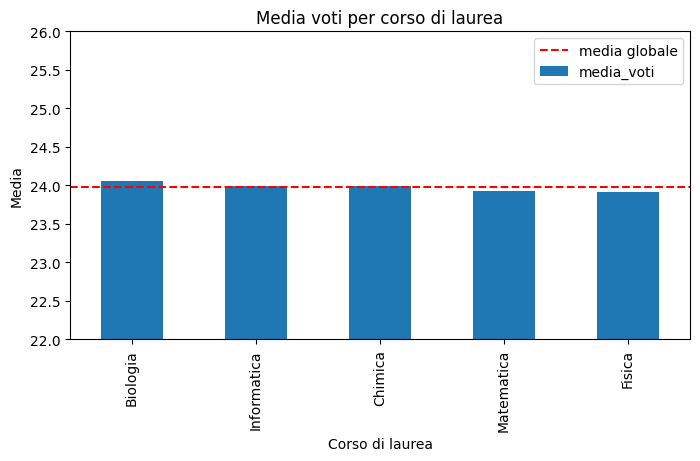

In [14]:
ax = df_stats.plot(
    x='corso_laurea', y=['media_voti'],
    kind='bar', figsize=(8, 4), legend=False,
    title='Media voti per corso di laurea'
)
ax.set_xlabel('Corso di laurea')
ax.set_ylabel('Media')
ax.set_ylim(22, 26)
ax.axhline(df_stats['media_voti'].mean(), color='red', linestyle='--', label='media globale')
ax.legend()

In [15]:
# Scrivi un DataFrame esterno nel DB
df_extra = pd.DataFrame({
    'matricola':    ['900001', '900002'],
    'cognome':      ['Neri',   'Bruni'],
    'nome':         ['Elena',  'Marco'],
    'anno_imm':     [2024,     2024],
    'corso_laurea': ['Informatica', 'Fisica'],
})
df_extra.to_sql('studenti', conn, if_exists='append', index=False)

conn.execute('SELECT COUNT(*) FROM studenti').fetchone()

(5002,)

### Workflow tipico con Pandas

```
fonte esterna (CSV / API / scraping)
        │
        ▼
   pd.DataFrame          ←── pulizia, normalizzazione
        │
   .to_sql()             ←── una volta sola
        │
     SQLite DB           ←── persiste tra sessioni
        │
   pd.read_sql()         ←── solo i dati che servono
        │
   pd.DataFrame          ←── analisi e visualizzazione
```

**Vantaggi pratici**:
- il DB occupa meno RAM rispetto a un DataFrame sempre in memoria
- le aggregazioni pesanti vengono fatte in C da SQLite
- più sessioni/processi possono leggere lo stesso DB senza copiare file

## Pulizia

Chiudiamo le connessioni e rimuoviamo i file temporanei.

In [16]:
import os

conn.close()
db.close()

for f in ['ateneo.db', 'vendite.db', 'concurrent.db',
          'vendite.csv', 'vendite.json',
          # file WAL e SHM creati automaticamente da SQLite
          'ateneo.db-wal', 'ateneo.db-shm',
          'vendite.db-wal', 'vendite.db-shm',
          'concurrent.db-wal', 'concurrent.db-shm']:
    if os.path.exists(f):
        os.remove(f)
        print(f'rimosso: {f}')

rimosso: ateneo.db
rimosso: vendite.db
rimosso: concurrent.db
rimosso: vendite.csv
rimosso: vendite.json
rimosso: concurrent.db-wal
rimosso: concurrent.db-shm
